# Deep Learning for Computer Vision:  HW 3


## Computer Science: COMS W 4995 006


### Due: October 26, 2021

#### Problem

a) You are given two dimensional input from three separate classes. Your task is to implement a multi-layer perceptron (MLP) 3-class classifier with multiple hidden layers and a regularization on the weights. For the activiation function of the hidden units use ReLU or leaky ReLU. For the predictions use softmax on a linear output layer as we did in class. Your loss layer should compute $-\log P(y = i \,|{\bf x})$ where $i$ is the correct label according to the training data.

Implement each layer type (hidden, output, and loss) as separate python classes, each with methods for initialization, forward propagation, and backpropagation.

Implement a MLP as its own class, with separate methods for initialization, adding a layer, forward propagation, backpropagation, training and prediction. 

Let the layer dimensions be parameters passed when the network is created.

Let the number of training epochs, the mini-batch size, and the regularization parameter be parameters that are passed when training the network.

Build and run your network using your own constructs. The code for doing this might look like what is shown in the next box below.

b) Show the decision regions of the trained classifier by densely generating points in the plane and color coding these points with the three different labels. 

c) Repeat varying the number of hidden units (3, 8, 16), the number of hidden layers (1 and 3), and the regularization value (0 and some other value of your choosing).

d) Re-use this same network on any data of your own choosing. You can increase the dimensionality of the features space as you like. You can also change the number of classes to just two or more than three to align with your data. Separate your data into three piles: training, testing, and validation. Use your testing data to decide when to stop training if appropriate. Use your validation set to compute the accuracy of you classfier. 

Using the same data as HW1: https://drive.google.com/drive/folders/1F5GstW_-G5gMGsYNLLvDU7XMCewrZI0A?usp=sharing
!pip install rasterio
!pip install matplotlib

In [1]:
# NN = MLP()
# NN.add_layer('Hidden', dim_in=2, dim_out=16)
# NN.add_layer('Hidden', dim_in=16, dim_out=16)
# NN.add_layer('Hidden', dim_in=16, dim_out=16)
# NN.add_layer('Output', dim_in=16, dim_out=3)
# NN.add_layer('Loss', dim_in=3, dim_out=3)

# loss = NN.train(X, y, epochs=100, bsize=8, alpha=0.0)
# plot_loss(loss)
# plot_decision_regions(NN)

 

#### NOTE:  Do not to use keras, tensorflow, pytorch, sklearn, etc. to do this.  You must build the machine learning components from scratch.  

#### YOUR CODE MUST BE YOUR OWN.
_______________________________________________________________



Let's start by importing some libraries.

In [2]:
import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

Let's make up our 2D data for our three classes.

In [3]:
data = pd.DataFrame(np.zeros((5000, 3)), columns=['x1', 'x2', 'y'])

# Let's make up some noisy XOR data to use to build our binary classifier
for i in range(len(data.index)):
    x1 = random.randint(0,1)
    x2 = random.randint(0,1)
    if x1 == 1 and x2 == 0:
        y = 0
    elif x1 == 0 and x2 == 1:
        y = 0
    elif x1 == 0 and x2 == 0:
        y = 1
    else:
        y = 2
    x1 = 1.0 * x1 + 0.20 * np.random.normal()
    x2 = 1.0 * x2 + 0.20 * np.random.normal()
    data.iloc[i,0] = x1
    data.iloc[i,1] = x2
    data.iloc[i,2] = y
    
for i in range(int(0.25 *len(data.index))):
    k = np.random.randint(len(data.index)-1)  
    data.iloc[k,0] = 1.5 + 0.20 * np.random.normal()
    data.iloc[k,1] = 1.5 + 0.20 * np.random.normal()
    data.iloc[k,2] = 1

for i in range(int(0.25 *len(data.index))):
    k = np.random.randint(len(data.index)-1)  
    data.iloc[k,0] = 0.5 + 0.20 * np.random.normal()
    data.iloc[k,1] = -0.75 + 0.20 * np.random.normal()
    data.iloc[k,2] = 2
    
# Now let's normalize this data.
data.iloc[:,0] = (data.iloc[:,0] - data['x1'].mean()) / data['x1'].std()
data.iloc[:,1] = (data.iloc[:,1] - data['x2'].mean()) / data['x2'].std()
        
data.head()

,x1,x2,y
0,0.963717,-0.430938,0.0
1,-0.035253,0.649216,2.0
2,-0.328197,-1.459381,2.0
3,-1.548394,-0.247729,1.0
4,-0.099571,0.902762,2.0


Let's message this data into a numpy format.

In [4]:
# set X (training data) and y (target variable)
cols = data.shape[1]
X = data.iloc[:,0:cols-1]
y = data.iloc[:,cols-1:cols]

# The cost function is expecting numpy matrices so we need to convert X and y before we can use them.  
X = np.matrix(X.values)
y = np.matrix(y.values)
X = X.A
y = y.A

Let's make a sloppy plotting function for our binary data.

In [5]:
# Sloppy function for plotting our data
def plot_data(X, y_predict):
    
    fig, ax = plt.subplots(figsize=(12,8))
    ax.margins(0.05) # Optional, just adds 5% padding to the autoscaling

    indices_0 = [k for k in range(0, X.shape[0]) if y_predict[k] == 0]
    indices_1 = [k for k in range(0, X.shape[0]) if y_predict[k] == 1]
    indices_2 = [k for k in range(0, X.shape[0]) if y_predict[k] == 2]

    ax.plot(X[indices_0, 0], X[indices_0,1], marker='o', linestyle='', ms=5, label='0')
    ax.plot(X[indices_1, 0], X[indices_1,1], marker='o', linestyle='', ms=5, label='1')
    ax.plot(X[indices_2, 0], X[indices_2,1], marker='o', linestyle='', ms=5, label='2')

    ax.legend()
    ax.legend(loc=2)
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    ax.set_title('Tricky 3 Class Classification')
    plt.show()

Now let's plot it.

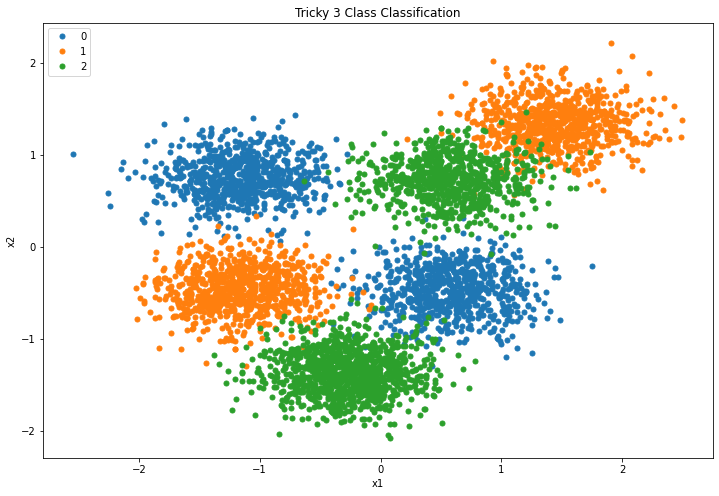

In [6]:
plot_data(X, y)

Now build your network. Good luck! 😉 

In [41]:
def plot_loss(loss):
    fig, ax = plt.subplots(figsize=(12,8))
    ax.margins(0.05) # Optional, just adds 5% padding to the autoscaling
    
    ax.plot(loss)
    ax.set_xlabel('Iterations')
    ax.set_ylabel('Loss')
    ax.set_title('Plot of loss with iterations')
    plt.show()
    
def plot_decision_regions(NN):
    
    fig, ax = plt.subplots(figsize=(12,8))
    ax.margins(0.05) # Optional, just adds 5% padding to the autoscaling
    

    #new data for decision regions
    X_decision = np.random.uniform(-3, 3, (100000, 2))
    y_predict = NN.predict(X_decision)
    indices_0 = [k for k in range(0, X_decision.shape[0]) if y_predict[k] == 0]
    indices_1 = [k for k in range(0, X_decision.shape[0]) if y_predict[k] == 1]
    indices_2 = [k for k in range(0, X_decision.shape[0]) if y_predict[k] == 2]
    ax.plot(X_decision[indices_0, 0], X_decision[indices_0,1], marker='o', linestyle='', ms=5, label='decision region 0')
    ax.plot(X_decision[indices_1, 0], X_decision[indices_1,1], marker='o', linestyle='', ms=5, label='decision region 1')
    ax.plot(X_decision[indices_2, 0], X_decision[indices_2,1], marker='o', linestyle='', ms=5, label='decision region 2')
    
    
    # plotting of binary data
    indices_0 = [k for k in range(0, X.shape[0]) if y[k] == 0]
    indices_1 = [k for k in range(0, X.shape[0]) if y[k] == 1]
    indices_2 = [k for k in range(0, X.shape[0]) if y[k] == 2]

    ax.plot(X[indices_0, 0], X[indices_0,1], marker='o', linestyle='', ms=5, label='0')
    ax.plot(X[indices_1, 0], X[indices_1,1], marker='o', linestyle='', ms=5, label='1')
    ax.plot(X[indices_2, 0], X[indices_2,1], marker='o', linestyle='', ms=5, label='2')
    
    ax.legend()
    ax.legend(loc=2)
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    ax.set_title('3 class classification')
    plt.show()
    
    print(f'Hidden units: {NN.hidden_layer_list[0].dim_out}, Hidden layers: {len(NN.hidden_layer_list)}\
          \nRegularization: {NN.alpha}, Batch size: {NN.bsize}, Epochs:{NN.epochs}, Accuracy: {NN.accuracy(X,y)}')

In [42]:
#using .reshape() to avoid overflow issues I had in the last Homework

class hidden_layer:
    def __init__(self, dim_in, dim_out):
        #initialization
        self.dim_in = dim_in
        self.dim_out = dim_out
        self.W = np.random.normal(0, 0.1, (dim_in, dim_out))
#         self.W = np.random.random((dim_in, dim_out))
#         self.c = np.random.random((1,dim_out))
        self.c = np.zeros((1,dim_out))
        
    def forward_propagation(self, X):
        h = np.maximum(np.dot(X, self.W) + self.c, np.zeros(self.c.shape))
        return h
    
    def backward_propagation(self, dL_dh, h, X, learning_rate, alpha):
#         a = np.dot(X, self.W) + self.c
#         f = 1.0 * (a > 0) #slope is 1 for a>0
        f = np.zeros(h.shape)
        f[np.nonzero(h)] = 1
        dL_db = np.multiply(f, dL_dh)
        dL_dW = np.dot(np.transpose(X), dL_db) + alpha * self.W
        dL_dc = np.mean(dL_db, axis = 0).reshape(1, self.dim_out)
        dL_dX = np.dot(dL_dc, np.transpose(self.W))
        self.W = self.W - learning_rate * dL_dW
        self.c = self.c - learning_rate * dL_dc
        return dL_dX
        
class output_layer:
    def __init__(self, dim_in, dim_out):
        #initialization
        self.dim_in = dim_in
        self.dim_out = dim_out
        self.W = np.random.normal(0, 0.1, (dim_in, dim_out))
#         self.W = np.random.random((dim_in, dim_out))
#         self.b = np.random.random((1,dim_out))
        self.b = np.zeros((1,dim_out))
        
    def forward_propagation(self, h):
        z = np.dot(h, self.W) + self.b
        z = z - np.max(z, axis=1).reshape(z.shape[0],1) #Ensuring the value of z does not increase too much
        return z
        
    def backward_propagation(self, dL_dz, h, learning_rate, alpha):
        dL_db = np.mean(dL_dz, axis=0).reshape(1, self.dim_out) 
#         dL_dW = h.T.dot(dL_dz) + alpha * self.W
        dL_dW = np.dot(np.transpose(h),dL_dz) + alpha * self.W
        dL_dh = np.dot(dL_dz, np.transpose(self.W))
        self.W = self.W - learning_rate * dL_dW
        self.b = self.b - learning_rate * dL_db
        return dL_dh
        
class loss_layer:
    def __init__(self, dim_in, dim_out):
        #initialization
        self.dim_in = dim_in
        self.dim_out = dim_out
        
    def forward_propagation(self, z, y):
        temp = -z + np.log(np.sum(np.exp(z), axis=1)).reshape(z.shape[0],1)
        L = temp[np.arange(z.shape[0]), y.flatten().astype(int)] #Genious implementation of indicator function
        return np.mean(L)
    
    def backward_propagation(self, z, y):
        temp = np.zeros(z.shape)
        temp[np.arange(z.shape[0]), y.flatten().astype(int)] = -1 #indicator function
        dL_dz = np.exp(z) / np.sum(np.exp(z),axis=1).reshape(z.shape[0],1) + temp
        return dL_dz

In [43]:
class MLP:
    def __init__(self):
        #initialization
        self.hidden_layer_list = []
        self.output_layer = None
        self.loss_layer = None
        self.learning_rate = None
        self.bsize = None
        self.epochs = None
        self.alpha = None
        
    def add_layer(self, case, dim_in, dim_out):
        if case=="Hidden": #hidden case layer
            self.hidden_layer_list.append(hidden_layer(dim_in, dim_out))
        elif case=="Output": #output case layer
            self.output_layer = output_layer(dim_in, dim_out)
        elif case=="Loss": #loss case layer
            self.loss_layer = loss_layer(dim_in, dim_out)

    
    def forward(self, X, y, alpha):
        hlist = []
        #forward pass through the layers
        for i in range(len(self.hidden_layer_list)):
            h = self.hidden_layer_list[i].forward_propagation(X)
            hlist.append(h)
            X = h
        z = self.output_layer.forward_propagation(h)
        L = self.loss_layer.forward_propagation(z, y)
        #L2 regularization, Wo and W
        for i in range(len(self.hidden_layer_list)):
            L += alpha/2 * np.linalg.norm(self.hidden_layer_list[i].W)**2 
        L += alpha/2 * np.linalg.norm(self.output_layer.W)**2
        return hlist, z, L
    
    def backward(self, hlist, z, X, y, learning_rate, alpha):
        #backward pass through the layers
        dL_dz = self.loss_layer.backward_propagation(z, y)
        dL_dh = self.output_layer.backward_propagation(dL_dz, hlist[-1], learning_rate, alpha)
        for i in range(len(self.hidden_layer_list)-1, 0, -1):
            dL_dX = self.hidden_layer_list[i].backward_propagation(dL_dh, hlist[i], hlist[i-1], learning_rate, alpha)
            dL_dh = dL_dX  
        # first layer
        dL_dX = self.hidden_layer_list[0].backward_propagation(dL_dh, hlist[0], X, learning_rate, alpha)

        
    def train(self, X, y, epochs, bsize, alpha, learning_rate):
        self.learning_rate = learning_rate
        self.bsize = bsize
        self.epochs = epochs
        self.alpha = alpha
        
        Dataset = np.concatenate((X, y), axis=1)
        loss = []
        for e in range(epochs):
            shuffle = np.random.permutation(Dataset)
            for i in range(int(Dataset.shape[0]/bsize)):
                X_batch = shuffle[bsize*i:bsize*(i+1), 0:2]
                y_batch = shuffle[bsize*i:bsize*(i+1), -1]
                hlist, z, L = self.forward(X, y, alpha)
                loss.append(L)
                self.backward(hlist, z, X, y, learning_rate, alpha)
        return loss
    
    def predict(self, X):
        for i in range(len(self.hidden_layer_list)):
            h = self.hidden_layer_list[i].forward_propagation(X)
            X = h
        z = self.output_layer.forward_propagation(h)
        y = np.argmax(z, axis=1)
        return y
    
    def accuracy(self, X, y):
        y_pred = self.predict(X)
        sum = 0
        for i,x in enumerate(y_pred):
            if x == y[i]: sum+=1        
        return sum/X.shape[0]

## 1 Hidden Layer, Regularization = 0

### 3 Hidden Units

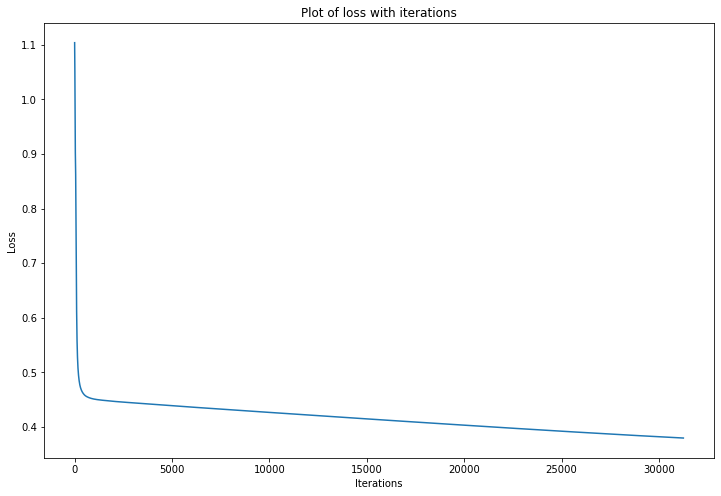

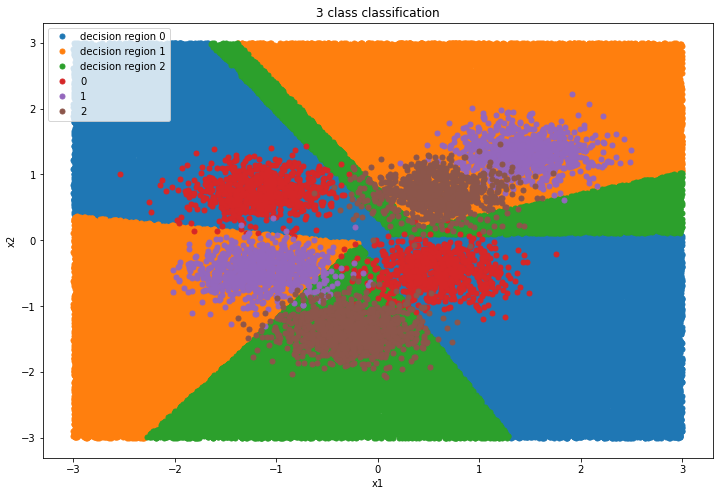

Hidden units: 3, Hidden layers: 1          
Regularization: 0.0, Batch size: 8, Epochs:50, Accuracy: 0.8324


In [10]:
NN = MLP()
NN.add_layer("Hidden", dim_in=2, dim_out=3) #add hidden layer
NN.add_layer("Output", dim_in=3, dim_out=3) #add output layer
NN.add_layer("Loss", dim_in=3, dim_out=3) #add loss layer

loss = NN.train(X, y, epochs=50, bsize=8, alpha=0.0, learning_rate=0.0001)

plot_loss(loss)
plot_decision_regions(NN)

### 8 Hidden Units

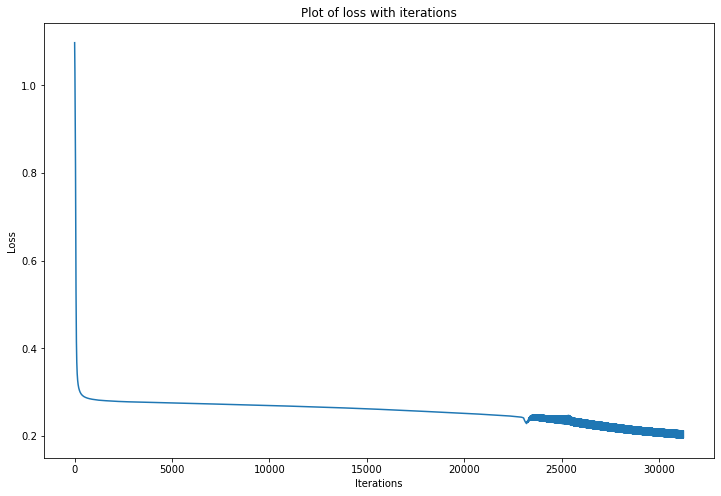

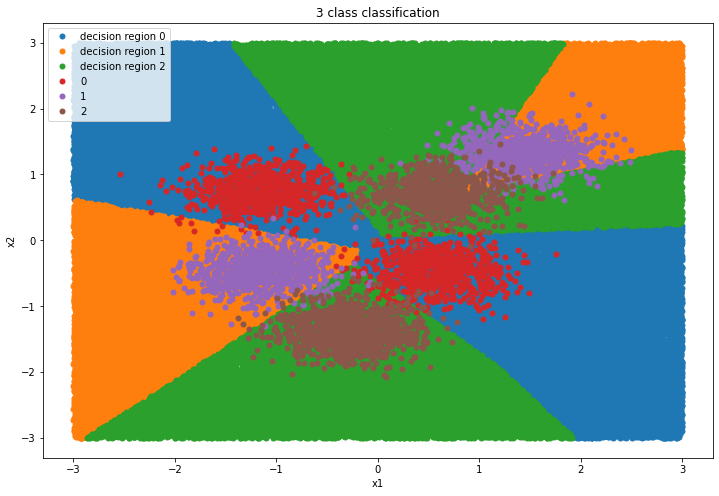

Hidden units: 8, Hidden layers: 1          
Regularization: 0.0, Batch size: 8, Epochs:50, Accuracy: 0.9286


In [11]:
NN = MLP()
NN.add_layer("Hidden", dim_in=2, dim_out=8) #add hidden layer
NN.add_layer("Output", dim_in=8, dim_out=3) #add output layer
NN.add_layer("Loss", dim_in=3, dim_out=3) #add loss layer

loss = NN.train(X, y, epochs=50, bsize=8, alpha=0.0, learning_rate=0.0001)

plot_loss(loss)
plot_decision_regions(NN)

### 16 Hidden Units

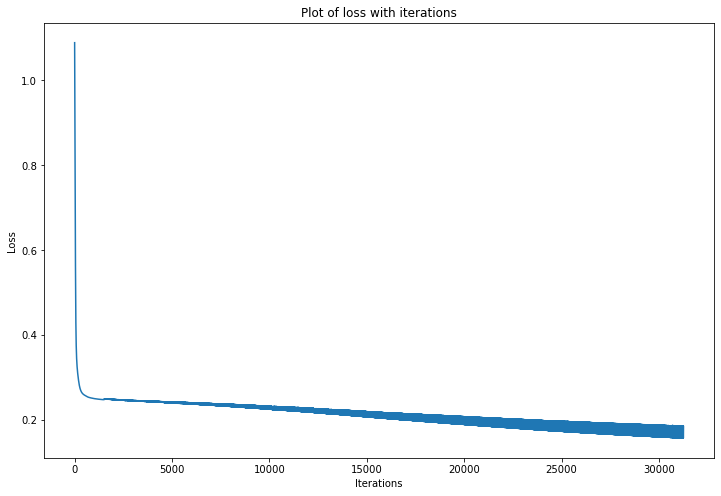

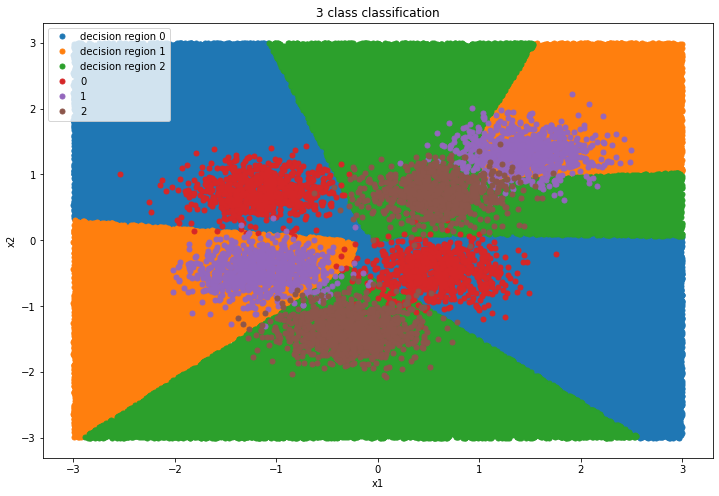

Hidden units: 16, Hidden layers: 1          
Regularization: 0.0, Batch size: 8, Epochs:50, Accuracy: 0.9472


In [12]:
NN = MLP()
NN.add_layer("Hidden", dim_in=2, dim_out=16) #add hidden layer
NN.add_layer("Output", dim_in=16, dim_out=3) #add output layer
NN.add_layer("Loss", dim_in=3, dim_out=3) #add loss layer

loss = NN.train(X, y, epochs=50, bsize=8, alpha=0.0, learning_rate=0.0001)

plot_loss(loss)
plot_decision_regions(NN)

## 3 Hidden Layers, Regularization = 0

### 3 Hidden Units

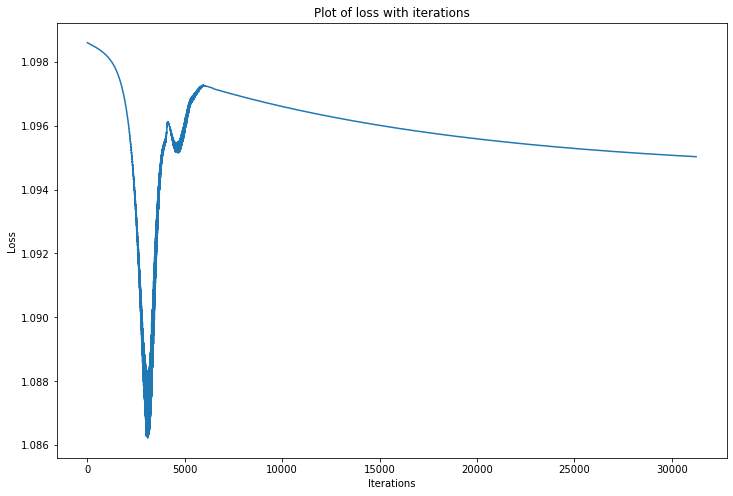

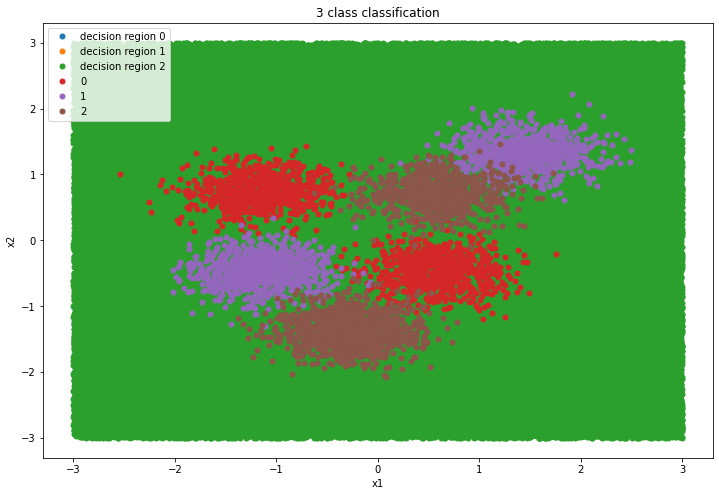

Hidden units: 3, Hidden layers: 3          
Regularization: 0.0, Batch size: 8, Epochs:50, Accuracy: 0.3736


In [13]:
NN = MLP()
NN.add_layer("Hidden", dim_in=2, dim_out=3) #add hidden layer
NN.add_layer("Hidden", dim_in=3, dim_out=3) #add hidden layer
NN.add_layer("Hidden", dim_in=3, dim_out=3) #add hidden layer
NN.add_layer("Output", dim_in=3, dim_out=3) #add output layer
NN.add_layer("Loss", dim_in=3, dim_out=3) #add loss layer

loss = NN.train(X, y, epochs=50, bsize=8, alpha=0.0, learning_rate=0.0001)

plot_loss(loss)
plot_decision_regions(NN)

### 8 Hidden Units

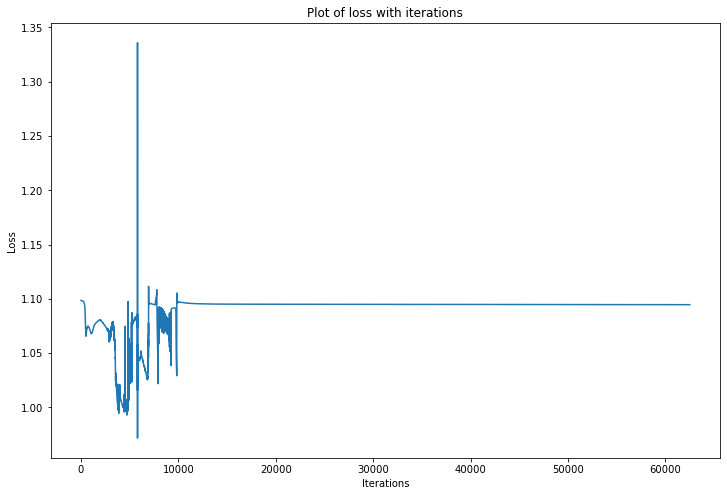

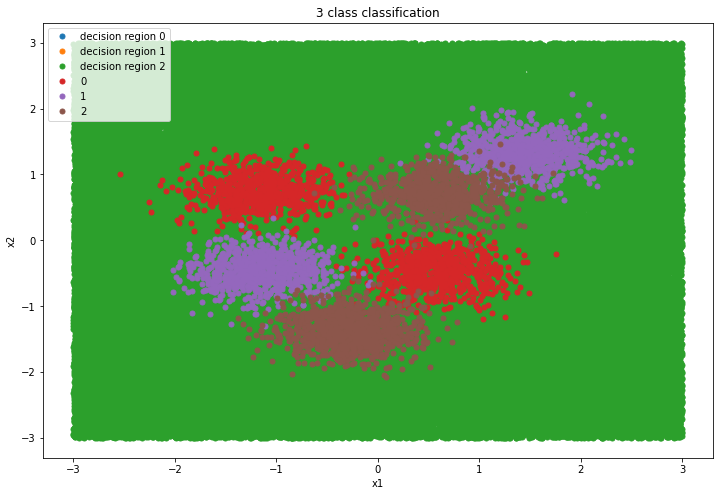

Hidden units: 8, Hidden layers: 3          
Regularization: 0.0, Batch size: 2, Epochs:25, Accuracy: 0.3736


In [14]:
NN = MLP()
NN.add_layer("Hidden", dim_in=2, dim_out=8) #add hidden layer
NN.add_layer("Hidden", dim_in=8, dim_out=8) #add hidden layer
NN.add_layer("Hidden", dim_in=8, dim_out=8) #add hidden layer
NN.add_layer("Output", dim_in=8, dim_out=3) #add output layer
NN.add_layer("Loss", dim_in=3, dim_out=3) #add loss layer

loss = NN.train(X, y, epochs=25, bsize=2, alpha=0.0, learning_rate=0.0001)

plot_loss(loss)
plot_decision_regions(NN)

### 16 Hidden Units

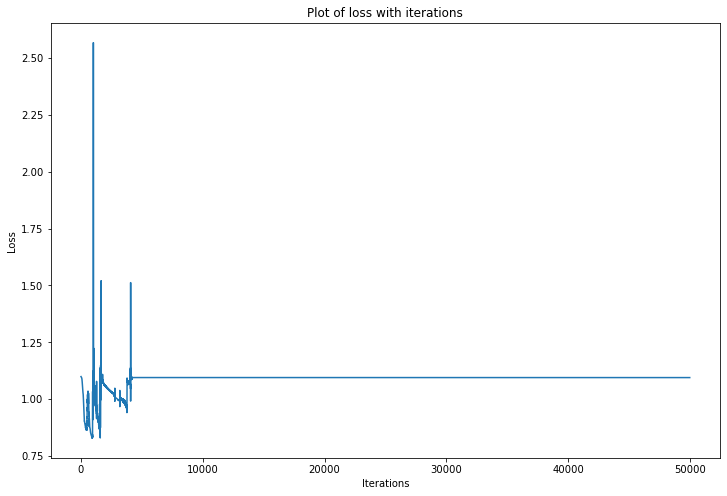

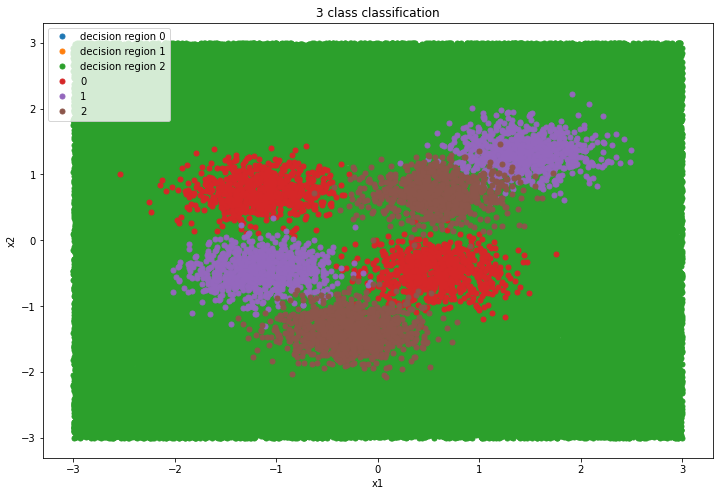

Hidden units: 16, Hidden layers: 3          
Regularization: 0.0, Batch size: 2, Epochs:20, Accuracy: 0.3736


In [15]:
NN = MLP()
NN.add_layer("Hidden", dim_in=2, dim_out=16) #add hidden layer
NN.add_layer("Hidden", dim_in=16, dim_out=16) #add hidden layer
NN.add_layer("Hidden", dim_in=16, dim_out=16) #add hidden layer
NN.add_layer("Output", dim_in=16, dim_out=3) #add output layer
NN.add_layer("Loss", dim_in=3, dim_out=3) #add loss layer

loss = NN.train(X, y, epochs=20, bsize=2, alpha=0.0, learning_rate=0.0001)

plot_loss(loss)
plot_decision_regions(NN)

## 1 Hidden Layer, Regularization = 0.1

### 3 Hidden Units

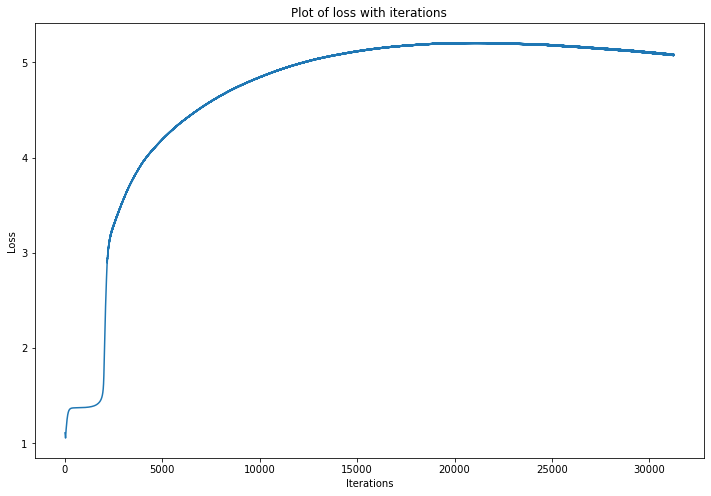

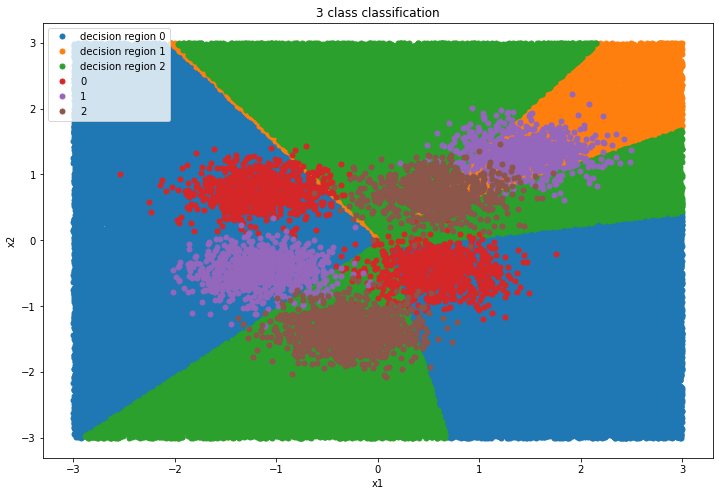

Hidden units: 3, Hidden layers: 1          
Regularization: 0.1, Batch size: 8, Epochs:50, Accuracy: 0.7252


In [16]:
NN = MLP()
NN.add_layer("Hidden", dim_in=2, dim_out=3) #add hidden layer
NN.add_layer("Output", dim_in=3, dim_out=3) #add output layer
NN.add_layer("Loss", dim_in=3, dim_out=3) #add loss layer

loss = NN.train(X, y, epochs=50, bsize=8, alpha=0.1, learning_rate=0.0001)

plot_loss(loss)
plot_decision_regions(NN)

### 8 Hidden Units

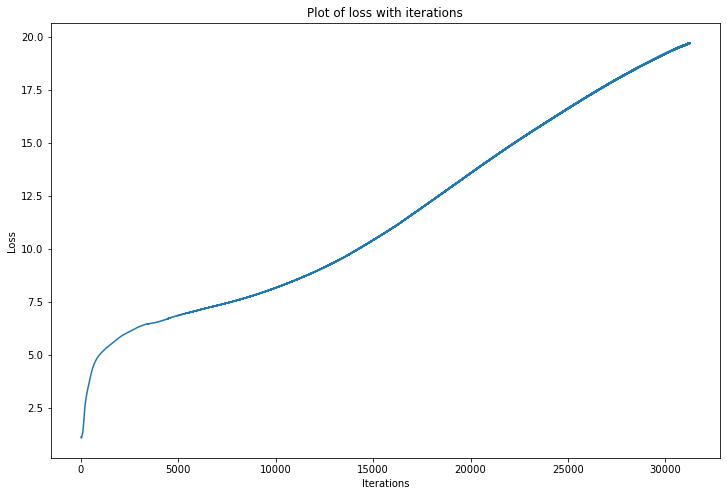

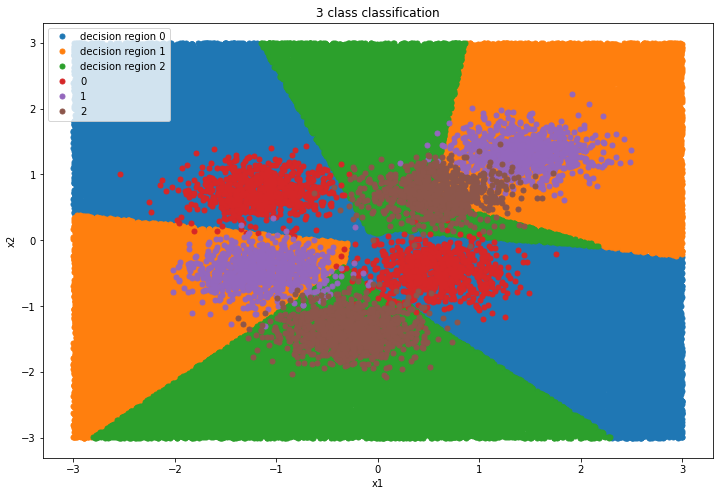

Hidden units: 8, Hidden layers: 1          
Regularization: 0.1, Batch size: 8, Epochs:50, Accuracy: 0.9158


In [17]:
NN = MLP()
NN.add_layer("Hidden", dim_in=2, dim_out=8) #add hidden layer
NN.add_layer("Output", dim_in=8, dim_out=3) #add output layer
NN.add_layer("Loss", dim_in=3, dim_out=3) #add loss layer

loss = NN.train(X, y, epochs=50, bsize=8, alpha=0.1, learning_rate=0.0001)

plot_loss(loss)
plot_decision_regions(NN)

### 16 Hidden Units

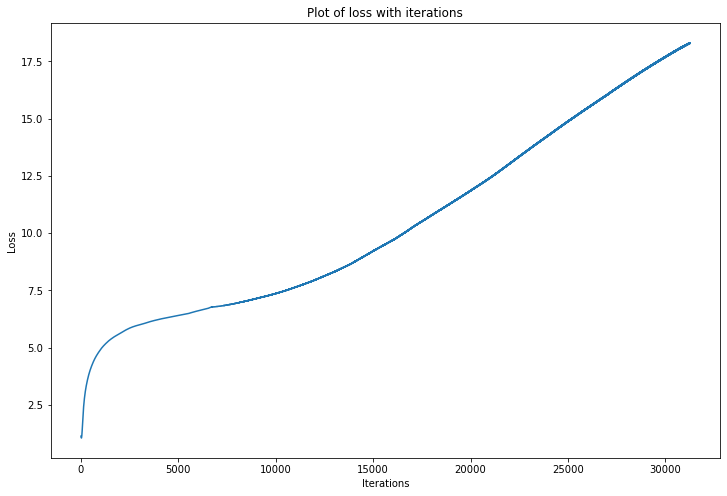

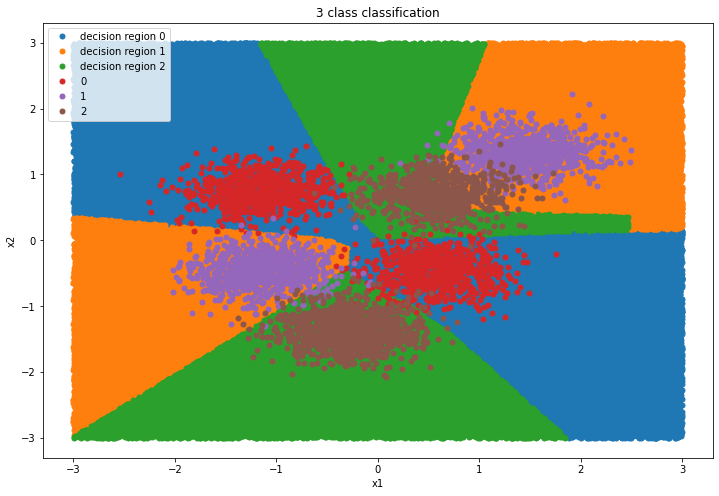

Hidden units: 16, Hidden layers: 1          
Regularization: 0.1, Batch size: 8, Epochs:50, Accuracy: 0.9092


In [18]:
NN = MLP()
NN.add_layer("Hidden", dim_in=2, dim_out=16) #add hidden layer
NN.add_layer("Output", dim_in=16, dim_out=3) #add output layer
NN.add_layer("Loss", dim_in=3, dim_out=3) #add loss layer

loss = NN.train(X, y, epochs=50, bsize=8, alpha=0.1, learning_rate=0.0001)

plot_loss(loss)
plot_decision_regions(NN)

## 3 Hidden Layers, Regularization = 0.1

### 3 Hidden Units

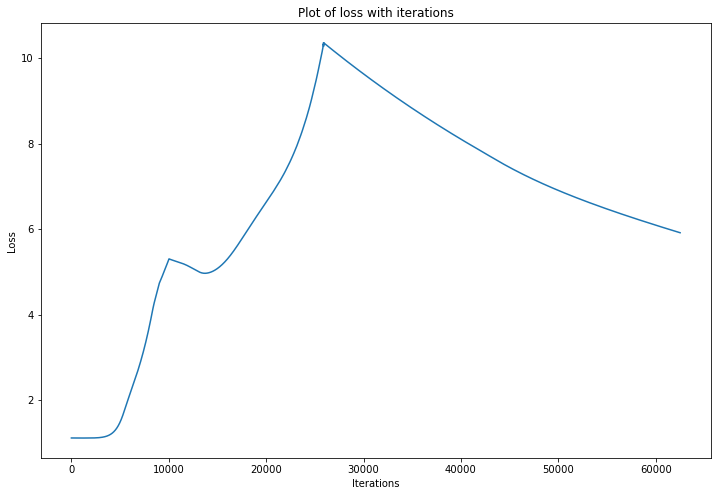

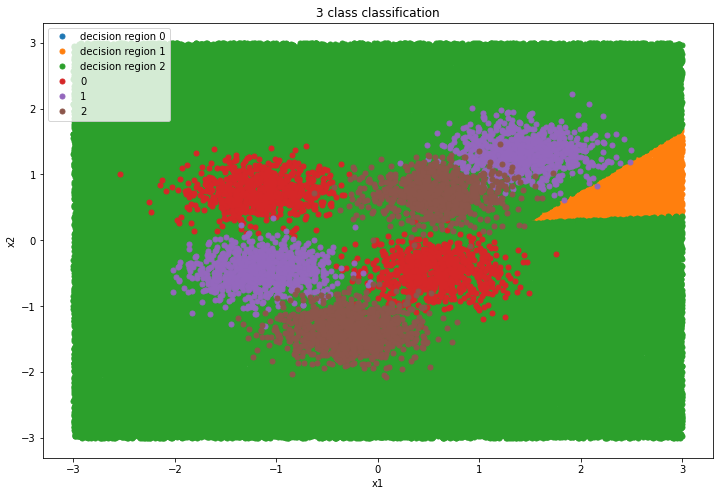

Hidden units: 3, Hidden layers: 3          
Regularization: 0.1, Batch size: 2, Epochs:25, Accuracy: 0.3742


In [19]:
NN = MLP()
NN.add_layer("Hidden", dim_in=2, dim_out=3) #add hidden layer
NN.add_layer("Hidden", dim_in=3, dim_out=3) #add hidden layer
NN.add_layer("Hidden", dim_in=3, dim_out=3) #add hidden layer
NN.add_layer("Output", dim_in=3, dim_out=3) #add output layer
NN.add_layer("Loss", dim_in=3, dim_out=3) #add loss layer

loss = NN.train(X, y, epochs=25, bsize=2, alpha=0.1, learning_rate=0.0001)

plot_loss(loss)
plot_decision_regions(NN)

### 8 Hidden Units

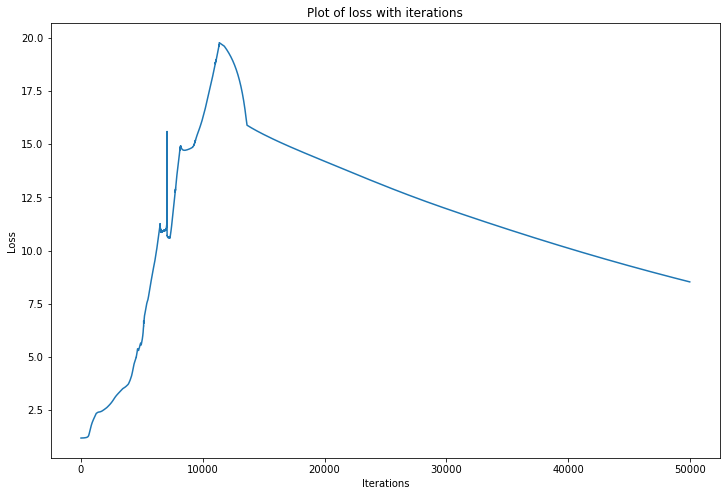

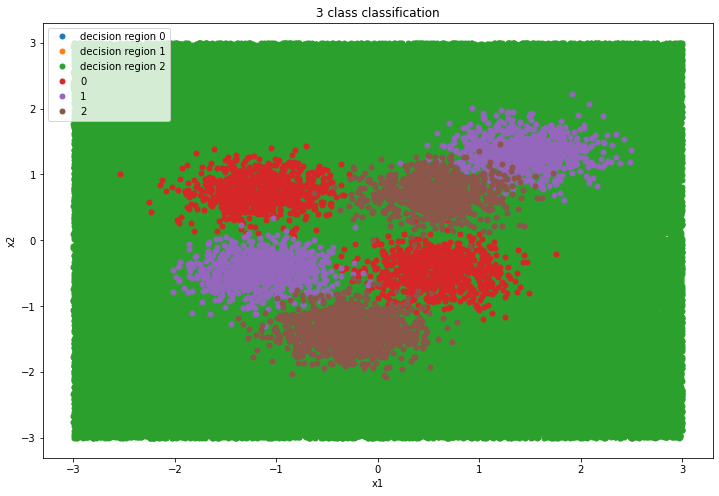

Hidden units: 8, Hidden layers: 3          
Regularization: 0.1, Batch size: 2, Epochs:20, Accuracy: 0.3736


In [20]:
NN = MLP()
NN.add_layer("Hidden", dim_in=2, dim_out=8) #add hidden layer
NN.add_layer("Hidden", dim_in=8, dim_out=8) #add hidden layer
NN.add_layer("Hidden", dim_in=8, dim_out=8) #add hidden layer
NN.add_layer("Output", dim_in=8, dim_out=3) #add output layer
NN.add_layer("Loss", dim_in=3, dim_out=3) #add loss layer

loss = NN.train(X, y, epochs=20, bsize=2, alpha=0.1, learning_rate=0.0001)

plot_loss(loss)
plot_decision_regions(NN)

### 16 Hidden Units

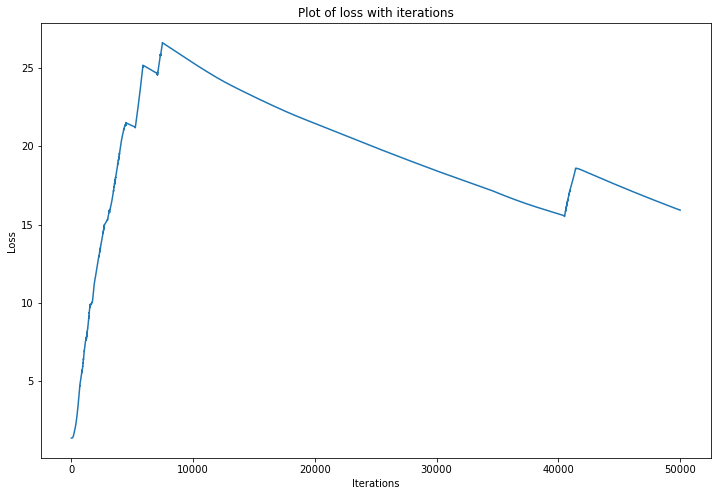

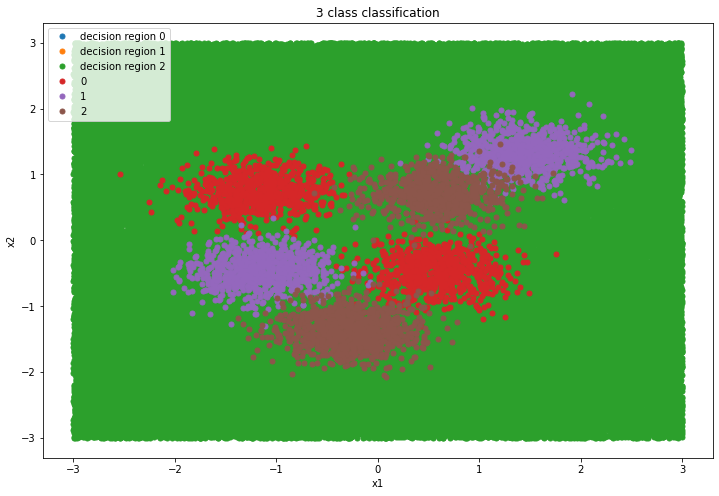

Hidden units: 16, Hidden layers: 3          
Regularization: 0.1, Batch size: 2, Epochs:20, Accuracy: 0.3736


In [21]:
NN = MLP()
NN.add_layer("Hidden", dim_in=2, dim_out=16) #add hidden layer
NN.add_layer("Hidden", dim_in=16, dim_out=16) #add hidden layer
NN.add_layer("Hidden", dim_in=16, dim_out=16) #add hidden layer
NN.add_layer("Output", dim_in=16, dim_out=3) #add output layer
NN.add_layer("Loss", dim_in=3, dim_out=3) #add loss layer

loss = NN.train(X, y, epochs=20, bsize=2, alpha=0.1, learning_rate=0.0001)

plot_loss(loss)
plot_decision_regions(NN)

# d

### Training on remote sensing data from HW1

In [22]:
import rasterio
from rasterio.plot import show
from rasterio.merge import merge
from matplotlib import pyplot
import math
import numpy as np
from rasterio.plot import show_hist

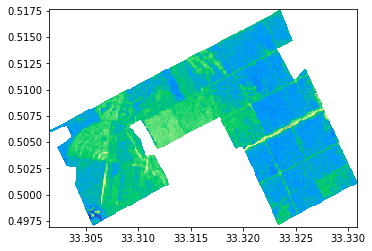

In [23]:
src = rasterio.open("C:/Users/hssid/Desktop/HW1/veg_training1.tif")
show(src, cmap='terrain')
img = src.read()[1]
meta = src.meta
red = img[np.where(img != meta['nodata'])]
img = src.read()[2]
green = img[np.where(img != meta['nodata'])]

stack=np.dstack((red,green))
stack = stack[0,:,:]

veg_training = pd.DataFrame(stack, columns = ['red','green'])
veg_training['veg'] = 1
# veg_training.head()

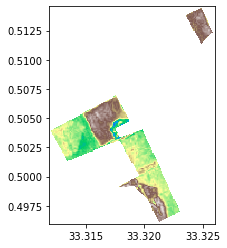

In [24]:
src = rasterio.open("C:/Users/hssid/Desktop/HW1/non_veg_training.tif")
show(src, cmap='terrain')
img = src.read()[1]
red = img[np.where(img != meta['nodata'])]
img = src.read()[2]
green = img[np.where(img != meta['nodata'])]

stack=np.dstack((red,green))
stack = stack[0,:,:]

non_veg_training = pd.DataFrame(stack, columns = ['red','green'])
non_veg_training['veg'] = 0
# non_veg_training.head()

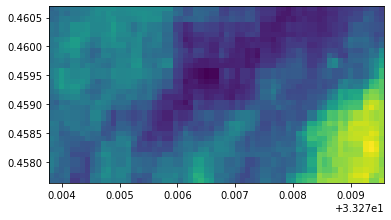

,red,green,veg
0,0.025384,0.946170,2
1,0.024659,0.946115,2
2,0.025067,0.944925,2
3,0.025489,0.944558,2
4,0.026338,0.943244,2


In [34]:
src = rasterio.open("C:/Users/hssid/Desktop/HW1/water.tif")
show(src)
img = src.read()[1]
meta = src.meta
red = img[np.where(img != meta['nodata'])]
img = src.read()[2]
green = img[np.where(img != meta['nodata'])]

stack=np.dstack((red,green))
stack = stack[0,:,:]

water_training = pd.DataFrame(stack, columns = ['red','green'])
water_training['veg'] = 2
# water_training.head()

In [35]:
train = pd.concat([veg_training, non_veg_training, water_training], ignore_index = True)
train.head(5)
train.head(-5)

,red,green,veg
0,2646.000000,634.000000,1
1,2616.000000,627.000000,1
2,2583.000000,589.000000,1
3,2609.000000,560.000000,1
4,2568.000000,551.000000,1
...,...,...,...
42336,0.021151,0.936138,2
42337,0.021151,0.935987,2
42338,0.021020,0.936260,2
42339,0.021567,0.934201,2


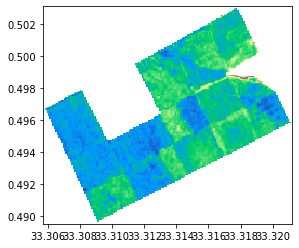

In [26]:
src = rasterio.open("C:/Users/hssid/Desktop/HW1/veg_test.tif")
show(src, cmap='terrain')

img = src.read()[1]
red = img[np.where(img != meta['nodata'])]
img = src.read()[2]
green = img[np.where(img != meta['nodata'])]

stack=np.dstack((red,green))
stack = stack[0,:,:]

veg_test = pd.DataFrame(stack, columns = ['red','green'])
veg_test['veg'] = 1

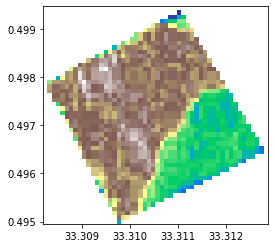

In [27]:
src = rasterio.open("C:/Users/hssid/Desktop/HW1/non_veg_test.tif")
show(src, cmap='terrain')

img = src.read()[1]
red = img[np.where(img != meta['nodata'])]
img = src.read()[2]
green = img[np.where(img != meta['nodata'])]

stack=np.dstack((red,green))
stack = stack[0,:,:]

non_veg_test = pd.DataFrame(stack, columns = ['red','green'])
non_veg_test['veg'] = 0

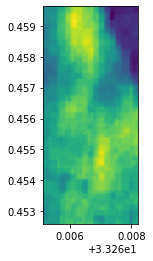

In [36]:
src = rasterio.open("C:/Users/hssid/Desktop/HW1/water1.tif")
show(src)
img = src.read()[1]
meta = src.meta
red = img[np.where(img != meta['nodata'])]
img = src.read()[2]
green = img[np.where(img != meta['nodata'])]

stack=np.dstack((red,green))
stack = stack[0,:,:]

water_test = pd.DataFrame(stack, columns = ['red','green'])
water_test['veg'] = 2
# water_training.head()

In [37]:
test = pd.concat([veg_test, non_veg_test, water_test], ignore_index = True)
test.head(5)
test.head(-5)

,red,green,veg
0,1983.000000,826.000000,1
1,2085.000000,790.000000,1
2,2359.000000,717.000000,1
3,2471.000000,685.000000,1
4,2332.000000,731.000000,1
...,...,...,...
15301,0.024777,0.945015,2
15302,0.023420,0.945727,2
15303,0.021336,0.946349,2
15304,0.022350,0.945718,2


In [38]:
# set X (training data) and y (target variable)
cols = train.shape[1]
X = train.iloc[:,0:cols-1]
y = train.iloc[:,cols-1:cols]

# set X (training data) and y (target variable)
cols = test.shape[1]
XX = test.iloc[:,0:cols-1]
yy = test.iloc[:,cols-1:cols]

# The cost function is expecting numpy matrices so we need to convert X and y before we can use them.  
X = np.matrix(X.values)
y = np.matrix(y.values)
XX = np.matrix(XX.values)
yy = np.matrix(yy.values)
print(X.shape, y.shape, XX.shape, yy.shape)

(42346, 2) (42346, 1) (15311, 2) (15311, 1)


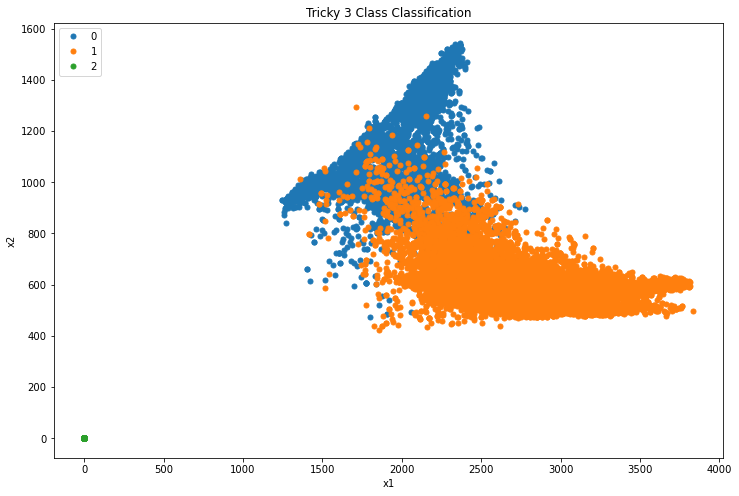

In [40]:
# Sloppy function for plotting our data
def plot_data(X, y_predict):
    
    fig, ax = plt.subplots(figsize=(12,8))
    ax.margins(0.05) # Optional, just adds 5% padding to the autoscaling

    indices_0 = [k for k in range(0, X.shape[0]) if y_predict[k] == 0]
    indices_1 = [k for k in range(0, X.shape[0]) if y_predict[k] == 1]
    indices_2 = [k for k in range(0, X.shape[0]) if y_predict[k] == 2]

    ax.plot(X[indices_0, 0], X[indices_0,1], marker='o', linestyle='', ms=5, label='0')
    ax.plot(X[indices_1, 0], X[indices_1,1], marker='o', linestyle='', ms=5, label='1')
    ax.plot(X[indices_2, 0], X[indices_2,1], marker='o', linestyle='', ms=5, label='2')

    ax.legend()
    ax.legend(loc=2)
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    ax.set_title('Tricky 3 Class Classification')
    plt.show()
plot_data(X, y)

In [45]:
NN = MLP()
NN.add_layer("Hidden", dim_in=2, dim_out=8) #add hidden layer
NN.add_layer("Output", dim_in=8, dim_out=3) #add output layer
NN.add_layer("Loss", dim_in=3, dim_out=3) #add loss layer

loss = NN.train(X, y, epochs=10, bsize=4, alpha=0.0, learning_rate=0.0001)

plot_loss(loss)
plot_decision_regions(NN)

KeyboardInterrupt: 

## Discussion
I added water to the classification of vegetation or not vegetation. Since Im looking at only green and red bands which mostly pick out sediment and vegtation so water has very low close to 0 values for both bands. Thats why in the original plot, points corresponding to water are clustered tightly around the origin at the bottom left of the plot. Now this is easy to classify and was added to introduce multiple classes to the land cover classification problem. But this problem requires a lot of computational power to be solved through MLP